In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

In [2]:
from google.colab import files
f = files.upload()

Saving country_profile_variables.csv to country_profile_variables.csv


In [3]:
# Step# 1
#

country = pd.read_csv('country_profile_variables.csv')
print(country.head(5))
print(country.tail(5))
print(country.shape)

print(type(country))

   Unnamed: 0         Country  Surface area (km2)  Population 1,000  (2017)  \
0           1     Afghanistan              652864                     35530   
1           2         Albania               28748                      2930   
2           3         Algeria             2381741                     41318   
3           4  American Samoa                 199                        56   
4           5          Angola             1246700                     29784   

   GDP (M US$)  Life Exp Female  Life Exp Male  
0        20270             63.5           61.0  
1        11541             79.9           75.6  
2       164779             76.5           74.1  
3          -99             77.8           71.1  
4       117955             63.0           57.4  
     Unnamed: 0                    Country  Surface area (km2)  \
206         207  Wallis and Futuna Islands                 142   
207         208             Western Sahara              266000   
208         209                  

In [4]:
lifeExpFemale = country['Life Exp Female']
lifeExpMale = country['Life Exp Male']

diffLE_MaleFemale = lifeExpFemale - lifeExpMale
averageLifeExp = (lifeExpFemale + lifeExpMale)/2
print(averageLifeExp)

0      62.25
1      77.75
2      75.30
3      74.45
4      60.20
       ...  
206    75.75
207    68.60
208    64.20
209    59.70
210    57.55
Length: 211, dtype: float64


In [5]:
country['averageLifeExp'] = averageLifeExp
country['Difference'] = diffLE_MaleFemale

print(country.head(5))

   Unnamed: 0         Country  Surface area (km2)  Population 1,000  (2017)  \
0           1     Afghanistan              652864                     35530   
1           2         Albania               28748                      2930   
2           3         Algeria             2381741                     41318   
3           4  American Samoa                 199                        56   
4           5          Angola             1246700                     29784   

   GDP (M US$)  Life Exp Female  Life Exp Male  averageLifeExp  Difference  
0        20270             63.5           61.0           62.25         2.5  
1        11541             79.9           75.6           77.75         4.3  
2       164779             76.5           74.1           75.30         2.4  
3          -99             77.8           71.1           74.45         6.7  
4       117955             63.0           57.4           60.20         5.6  


In [7]:
sortedTable = country.sort_values(['Difference'],ascending=False)
print(sortedTable.head(5))
print(sortedTable.shape)
sortedTable.loc[sortedTable['Country'] ==  'United States of America']

     Unnamed: 0               Country  Surface area (km2)  \
182         183  Syrian Arab Republic              185180   
154         155    Russian Federation            17098246   
16           17               Belarus              207600   
107         108             Lithuania               65286   
102         103                Latvia               64573   

     Population 1,000  (2017)  GDP (M US$)  Life Exp Female  Life Exp Male  \
182                     18270        28393             76.3           64.4   
154                    143990      1326016             75.9           64.7   
16                       9468        54609             77.7           66.5   
107                      2890        41402             79.3           68.5   
102                      1950        27004             78.7           68.8   

     averageLifeExp  Difference  
182           70.35        11.9  
154           70.30        11.2  
16            72.10        11.2  
107           73.90        1

,Unnamed: 0,Country,Surface area (km2),"Population 1,000 (2017)",GDP (M US$),Life Exp Female,Life Exp Male,averageLifeExp,Difference
199,200,United States of America,9833517,324460,18036648,81.2,76.5,78.85,4.7


In [8]:
countryName = country['Country']
GDP = country['GDP (M US$)']
averageLifeExp = sortedTable['averageLifeExp']

marker_size_P = country['Population 1,000  (2017)']/1000 # Proportional to the Population
marker_size_SA = country['Surface area (km2)']/10000 # Proportional to the Surface Area


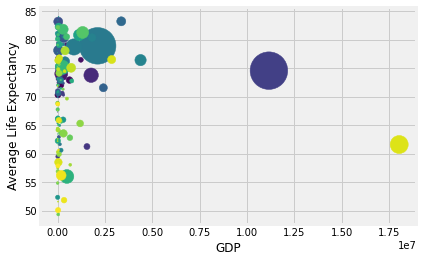

In [9]:
fig, ax = plt.subplots()

ax.scatter(GDP, averageLifeExp, s=marker_size_P, c = range(len(countryName)))
ax.set_xlabel("GDP")
ax.set_ylabel("Average Life Expectancy")
plt.show()

/usr/local/lib/python3.9/dist-packages/matplotlib/collections.py:963: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


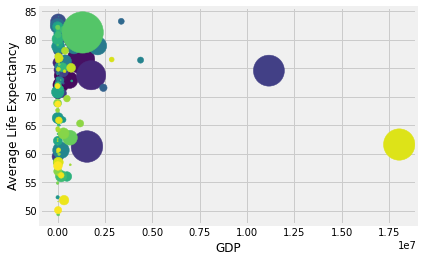

In [10]:
fig, ax = plt.subplots()

ax.scatter(GDP, averageLifeExp, s=marker_size_SA, c = range(len(countryName)))
ax.set_xlabel("GDP")
ax.set_ylabel("Average Life Expectancy")
plt.show()

/usr/local/lib/python3.9/dist-packages/pandas/core/arraylike.py:397: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


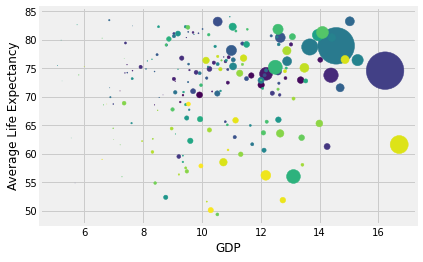

In [11]:
fig, ax = plt.subplots()

ax.scatter(np.log(GDP), averageLifeExp, s=marker_size_P, c = range(len(countryName)))
ax.set_xlabel("GDP")
ax.set_ylabel("Average Life Expectancy")
plt.show()

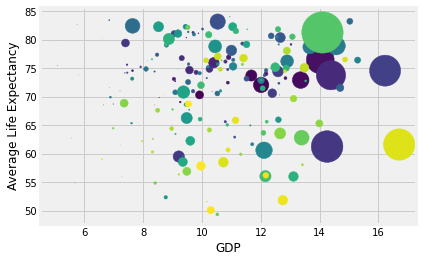

In [12]:
fig, ax = plt.subplots()

ax.scatter(np.log(GDP), averageLifeExp, s=marker_size_SA, c = range(len(countryName)))
ax.set_xlabel("GDP")
ax.set_ylabel("Average Life Expectancy")
plt.show()